# Project FORESIGHT — Inventory Risk Analysis

## AI-Powered Demand & Inventory Intelligence Platform

### Inventory Risk Assessment

This notebook analyzes inventory conditions at SKU and date level to identify:

- Stockout risk
- Low-stock conditions
- Reorder-point breaches
- Inventory coverage
- Incoming stock
- Lead-time related risk
- Potential inventory risk categories

The analysis combines inventory data with historical demand information to support inventory-risk identification and downstream replenishment recommendations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Inventory and Demand Data

The inventory dataset contains daily stock information for each SKU.

The demand dataset provides historical units sold, which will be used to estimate demand pressure and inventory coverage.

In [2]:
# Load inventory and demand data

inventory = pd.read_csv(
    "../data/processed/inventory_clean.csv"
)

sales = pd.read_csv(
    "../data/processed/sales_clean.csv"
)

# Convert dates
inventory["date"] = pd.to_datetime(
    inventory["date"],
    errors="coerce"
)

sales["date"] = pd.to_datetime(
    sales["date"],
    errors="coerce"
)

# Standardize SKU IDs
inventory["sku_id"] = (
    inventory["sku_id"]
    .astype(str)
    .str.strip()
    .str.upper()
)

sales["sku_id"] = (
    sales["sku_id"]
    .astype(str)
    .str.strip()
    .str.upper()
)

print("Inventory shape:", inventory.shape)
print("Sales shape:", sales.shape)

print("\nInventory columns:")
print(inventory.columns.tolist())

print("\nSales columns:")
print(sales.columns.tolist())

Inventory shape: (21840, 7)
Sales shape: (20906, 9)

Inventory columns:
['date', 'sku_id', 'on_hand_units', 'on_order_units', 'lead_time_days', 'reorder_point', 'inventory_quality_flag']

Sales columns:
['date', 'sku_id', 'units_sold', 'revenue', 'price', 'promo_flag', 'calculated_revenue', 'revenue_difference', 'revenue_consistency_flag']


## 3. Inventory Data Quality Check

Before calculating inventory risk, we validate the key inventory fields for missing values, duplicate records, and invalid negative quantities.

In [3]:
# Check inventory data quality

print("Missing values:")
display(inventory[
    [
        "date",
        "sku_id",
        "on_hand_units",
        "on_order_units",
        "lead_time_days",
        "reorder_point"
    ]
].isnull().sum())

print("\nDuplicate rows:")
print(inventory.duplicated().sum())

print("\nNegative values:")
print("Negative on-hand units:",
      (inventory["on_hand_units"] < 0).sum())

print("Negative on-order units:",
      (inventory["on_order_units"] < 0).sum())

print("Negative lead-time days:",
      (inventory["lead_time_days"] < 0).sum())

print("Negative reorder points:",
      (inventory["reorder_point"] < 0).sum())

Missing values:


date               0
sku_id             0
on_hand_units     40
on_order_units     0
lead_time_days     0
reorder_point      0
dtype: int64


Duplicate rows:
0

Negative values:
Negative on-hand units: 1
Negative on-order units: 0
Negative lead-time days: 0
Negative reorder points: 0


## 4. Daily Demand Estimation

Historical units sold are aggregated by SKU and date to represent daily demand.

This demand information will be used to estimate how quickly available inventory may be consumed.

In [4]:
# Calculate daily demand by SKU

daily_demand = (
    sales.groupby(["date", "sku_id"])["units_sold"]
    .sum()
    .reset_index()
    .rename(columns={"units_sold": "daily_demand"})
)

print("Daily demand shape:", daily_demand.shape)

display(daily_demand.head(10))

Daily demand shape: (20906, 3)


,date,sku_id,daily_demand
0,2025-01-01,SKU001,52.0
1,2025-01-01,SKU003,8.0
2,2025-01-01,SKU005,83.0
3,2025-01-01,SKU006,22.0
4,2025-01-01,SKU007,72.0
5,2025-01-01,SKU008,79.0
6,2025-01-01,SKU009,18.0
7,2025-01-01,SKU012,39.0
8,2025-01-01,SKU016,73.0
9,2025-01-01,SKU018,59.0


In [5]:
# Merge daily demand with inventory information

inventory_risk = inventory.merge(
    daily_demand,
    on=["date", "sku_id"],
    how="left"
)

# If no sales were recorded for a SKU-date, treat demand as zero
inventory_risk["daily_demand"] = (
    inventory_risk["daily_demand"]
    .fillna(0)
)

print("Inventory risk dataset shape:", inventory_risk.shape)

display(inventory_risk.head(10))

Inventory risk dataset shape: (21840, 8)


,date,sku_id,on_hand_units,on_order_units,lead_time_days,reorder_point,inventory_quality_flag,daily_demand
0,2025-01-01,SKU001,284.0,125,6.0,255,OK,52.0
1,2025-01-02,SKU001,215.0,128,6.0,255,OK,69.0
2,2025-01-03,SKU001,166.0,186,6.0,255,OK,49.0
3,2025-01-04,SKU001,92.0,62,6.0,255,OK,74.0
4,2025-01-05,SKU001,49.0,112,6.0,255,OK,43.0
5,2025-01-06,SKU001,50.0,0,6.0,255,OK,56.0
6,2025-01-07,SKU001,4.0,64,6.0,255,OK,46.0
7,2025-01-08,SKU001,0.0,127,6.0,255,OK,51.0
8,2025-01-09,SKU001,0.0,43,6.0,255,OK,65.0
9,2025-01-10,SKU001,0.0,49,6.0,255,OK,70.0


## 5. Calculate Average Daily Demand

Average daily demand is calculated for each SKU using historical sales data.

This metric provides a more stable estimate of demand than a single day's sales and will be used to estimate inventory coverage.

In [6]:
# Calculate average daily demand for each SKU

average_demand = (
    daily_demand
    .groupby("sku_id")["daily_demand"]
    .mean()
    .reset_index()
    .rename(columns={"daily_demand": "average_daily_demand"})
)

inventory_risk = inventory_risk.merge(
    average_demand,
    on="sku_id",
    how="left"
)

print("Average daily demand calculated successfully.")

display(
    inventory_risk[
        ["sku_id", "daily_demand", "average_daily_demand"]
    ].head(10)
)

Average daily demand calculated successfully.


,sku_id,daily_demand,average_daily_demand
0,SKU001,52.0,58.959707
1,SKU001,69.0,58.959707
2,SKU001,49.0,58.959707
3,SKU001,74.0,58.959707
4,SKU001,43.0,58.959707
5,SKU001,56.0,58.959707
6,SKU001,46.0,58.959707
7,SKU001,51.0,58.959707
8,SKU001,65.0,58.959707
9,SKU001,70.0,58.959707


## 6. Calculate Inventory Coverage

Inventory coverage estimates how many days the current on-hand inventory can support expected demand.

**Inventory Coverage Days = On-Hand Units / Average Daily Demand**

A lower coverage value indicates greater potential stockout risk.

In [7]:
# Calculate inventory coverage in days

inventory_risk["inventory_coverage_days"] = np.where(
    inventory_risk["average_daily_demand"] > 0,
    inventory_risk["on_hand_units"] /
    inventory_risk["average_daily_demand"],
    np.inf
)

display(
    inventory_risk[
        [
            "date",
            "sku_id",
            "on_hand_units",
            "average_daily_demand",
            "inventory_coverage_days"
        ]
    ].head(10)
)

,date,sku_id,on_hand_units,average_daily_demand,inventory_coverage_days
0,2025-01-01,SKU001,284.0,58.959707,4.816849
1,2025-01-02,SKU001,215.0,58.959707,3.646558
2,2025-01-03,SKU001,166.0,58.959707,2.815482
3,2025-01-04,SKU001,92.0,58.959707,1.560388
4,2025-01-05,SKU001,49.0,58.959707,0.831076
5,2025-01-06,SKU001,50.0,58.959707,0.848037
6,2025-01-07,SKU001,4.0,58.959707,0.067843
7,2025-01-08,SKU001,0.0,58.959707,0.000000
8,2025-01-09,SKU001,0.0,58.959707,0.000000
9,2025-01-10,SKU001,0.0,58.959707,0.000000


## 7. Identify Reorder-Point Breaches

A reorder-point breach occurs when the available on-hand inventory falls below the defined reorder point.

These records represent situations where replenishment may need to be considered.

In [8]:
# Identify reorder-point breaches

inventory_risk["below_reorder_point"] = (
    inventory_risk["on_hand_units"] <
    inventory_risk["reorder_point"]
)

print("Records below reorder point:",
      inventory_risk["below_reorder_point"].sum())

display(
    inventory_risk[
        [
            "date",
            "sku_id",
            "on_hand_units",
            "reorder_point",
            "below_reorder_point"
        ]
    ].head(10)
)

Records below reorder point: 20652


,date,sku_id,on_hand_units,reorder_point,below_reorder_point
0,2025-01-01,SKU001,284.0,255,False
1,2025-01-02,SKU001,215.0,255,True
2,2025-01-03,SKU001,166.0,255,True
3,2025-01-04,SKU001,92.0,255,True
4,2025-01-05,SKU001,49.0,255,True
5,2025-01-06,SKU001,50.0,255,True
6,2025-01-07,SKU001,4.0,255,True
7,2025-01-08,SKU001,0.0,255,True
8,2025-01-09,SKU001,0.0,255,True
9,2025-01-10,SKU001,0.0,255,True


## 8. Identify Stockout Conditions

A stockout occurs when the available on-hand inventory reaches zero or below.

Stockout records are important indicators of potential lost-sales risk and insufficient inventory availability.

In [9]:
# Identify stockout conditions

inventory_risk["stockout_flag"] = (
    inventory_risk["on_hand_units"] <= 0
)

print(
    "Total stockout records:",
    inventory_risk["stockout_flag"].sum()
)

display(
    inventory_risk[
        [
            "date",
            "sku_id",
            "on_hand_units",
            "daily_demand",
            "stockout_flag"
        ]
    ].head(10)
)

Total stockout records: 15972


,date,sku_id,on_hand_units,daily_demand,stockout_flag
0,2025-01-01,SKU001,284.0,52.0,False
1,2025-01-02,SKU001,215.0,69.0,False
2,2025-01-03,SKU001,166.0,49.0,False
3,2025-01-04,SKU001,92.0,74.0,False
4,2025-01-05,SKU001,49.0,43.0,False
5,2025-01-06,SKU001,50.0,56.0,False
6,2025-01-07,SKU001,4.0,46.0,False
7,2025-01-08,SKU001,0.0,51.0,True
8,2025-01-09,SKU001,0.0,65.0,True
9,2025-01-10,SKU001,0.0,70.0,True


## 9. Lead-Time Demand Requirement

Lead-time demand estimates the quantity of inventory expected to be consumed while waiting for replenishment.

**Lead-Time Demand = Average Daily Demand × Lead Time Days**

Comparing lead-time demand with available inventory helps identify SKUs that may run out before replenishment arrives.

In [10]:
# Calculate expected demand during the replenishment lead time

inventory_risk["lead_time_demand"] = (
    inventory_risk["average_daily_demand"] *
    inventory_risk["lead_time_days"]
)

inventory_risk["lead_time_risk"] = (
    inventory_risk["on_hand_units"] <
    inventory_risk["lead_time_demand"]
)

print(
    "Records with lead-time inventory risk:",
    inventory_risk["lead_time_risk"].sum()
)

display(
    inventory_risk[
        [
            "date",
            "sku_id",
            "on_hand_units",
            "average_daily_demand",
            "lead_time_days",
            "lead_time_demand",
            "lead_time_risk"
        ]
    ].head(10)
)

Records with lead-time inventory risk: 20925


,date,sku_id,on_hand_units,average_daily_demand,lead_time_days,lead_time_demand,lead_time_risk
0,2025-01-01,SKU001,284.0,58.959707,6.0,353.758242,True
1,2025-01-02,SKU001,215.0,58.959707,6.0,353.758242,True
2,2025-01-03,SKU001,166.0,58.959707,6.0,353.758242,True
3,2025-01-04,SKU001,92.0,58.959707,6.0,353.758242,True
4,2025-01-05,SKU001,49.0,58.959707,6.0,353.758242,True
5,2025-01-06,SKU001,50.0,58.959707,6.0,353.758242,True
6,2025-01-07,SKU001,4.0,58.959707,6.0,353.758242,True
7,2025-01-08,SKU001,0.0,58.959707,6.0,353.758242,True
8,2025-01-09,SKU001,0.0,58.959707,6.0,353.758242,True
9,2025-01-10,SKU001,0.0,58.959707,6.0,353.758242,True


## 10. Overall Inventory Risk Classification

Inventory risk is classified using multiple indicators:

- **Stockout:** On-hand inventory is zero.
- **Critical:** Inventory is below lead-time demand and has very low coverage.
- **High:** Inventory is below the reorder point or has insufficient lead-time coverage.
- **Medium:** Inventory coverage is relatively low.
- **Low:** Inventory has sufficient coverage and is above the reorder point.

This classification provides a simple business-oriented view of inventory risk for each SKU-date combination.

In [11]:
# Assign an overall inventory risk category

def classify_inventory_risk(row):
    if row["stockout_flag"]:
        return "Critical"
    
    elif row["inventory_coverage_days"] <= row["lead_time_days"]:
        return "High"
    
    elif row["below_reorder_point"]:
        return "High"
    
    elif row["inventory_coverage_days"] <= 14:
        return "Medium"
    
    else:
        return "Low"


inventory_risk["risk_category"] = (
    inventory_risk.apply(
        classify_inventory_risk,
        axis=1
    )
)

print("Inventory risk classification completed.")

display(
    inventory_risk[
        [
            "date",
            "sku_id",
            "on_hand_units",
            "inventory_coverage_days",
            "below_reorder_point",
            "stockout_flag",
            "risk_category"
        ]
    ].head(15)
)

Inventory risk classification completed.


,date,sku_id,on_hand_units,inventory_coverage_days,below_reorder_point,stockout_flag,risk_category
0,2025-01-01,SKU001,284.0,4.816849,False,False,High
1,2025-01-02,SKU001,215.0,3.646558,True,False,High
2,2025-01-03,SKU001,166.0,2.815482,True,False,High
3,2025-01-04,SKU001,92.0,1.560388,True,False,High
4,2025-01-05,SKU001,49.0,0.831076,True,False,High
5,2025-01-06,SKU001,50.0,0.848037,True,False,High
6,2025-01-07,SKU001,4.0,0.067843,True,False,High
7,2025-01-08,SKU001,0.0,0.000000,True,True,Critical
8,2025-01-09,SKU001,0.0,0.000000,True,True,Critical
9,2025-01-10,SKU001,0.0,0.000000,True,True,Critical


## 11. Inventory Risk Distribution

This section summarizes the number of inventory records in each risk category.

The distribution helps identify the overall level of inventory pressure across the dataset.

In [12]:
# Count inventory records by risk category

risk_summary = (
    inventory_risk["risk_category"]
    .value_counts()
    .rename_axis("risk_category")
    .reset_index(name="record_count")
)

risk_summary

,risk_category,record_count
0,Critical,15972
1,High,4953
2,Low,504
3,Medium,411


## 12. SKU-Level Inventory Risk Summary

Inventory risk is aggregated at SKU level to identify products that experience frequent stockouts, reorder-point breaches, or high-risk inventory conditions.

In [13]:
# Create SKU-level inventory risk summary

sku_risk_summary = (
    inventory_risk
    .groupby("sku_id")
    .agg(
        total_records=("sku_id", "size"),
        stockout_records=("stockout_flag", "sum"),
        reorder_point_breaches=("below_reorder_point", "sum"),
        lead_time_risk_records=("lead_time_risk", "sum"),
        average_on_hand_units=("on_hand_units", "mean"),
        average_coverage_days=("inventory_coverage_days", "mean")
    )
    .reset_index()
)

# Calculate stockout rate
sku_risk_summary["stockout_rate"] = (
    sku_risk_summary["stockout_records"] /
    sku_risk_summary["total_records"]
)

# Sort by stockout frequency
sku_risk_summary = sku_risk_summary.sort_values(
    ["stockout_records", "reorder_point_breaches"],
    ascending=False
)

display(sku_risk_summary.head(10))

,sku_id,total_records,stockout_records,reorder_point_breaches,lead_time_risk_records,average_on_hand_units,average_coverage_days,stockout_rate
5,SKU006,546,497,545,545,1.137615,0.080573,0.910256
35,SKU036,546,495,545,545,3.064220,0.081138,0.906593
17,SKU018,546,494,546,546,6.721612,0.081423,0.904762
24,SKU025,546,493,542,542,5.987085,0.087783,0.902930
9,SKU010,546,489,546,546,11.734432,0.206820,0.895604
34,SKU035,546,484,545,545,9.744954,0.138475,0.886447
26,SKU027,546,480,545,545,4.752294,0.130665,0.879121
6,SKU007,546,479,544,544,12.317431,0.138273,0.877289
10,SKU011,546,478,545,545,23.855046,0.217368,0.875458
27,SKU028,546,473,546,546,9.591575,0.135474,0.866300


## 13. Highest-Risk SKUs

The following SKUs are ranked based on the number of stockout records and reorder-point breaches.

These products can be prioritized for deeper inventory investigation and future replenishment recommendations.

In [14]:
# Display the 10 highest-risk SKUs

top_risk_skus = (
    sku_risk_summary[
        [
            "sku_id",
            "stockout_records",
            "reorder_point_breaches",
            "lead_time_risk_records",
            "average_on_hand_units",
            "average_coverage_days",
            "stockout_rate"
        ]
    ]
    .head(10)
)

top_risk_skus

,sku_id,stockout_records,reorder_point_breaches,lead_time_risk_records,average_on_hand_units,average_coverage_days,stockout_rate
5,SKU006,497,545,545,1.137615,0.080573,0.910256
35,SKU036,495,545,545,3.064220,0.081138,0.906593
17,SKU018,494,546,546,6.721612,0.081423,0.904762
24,SKU025,493,542,542,5.987085,0.087783,0.902930
9,SKU010,489,546,546,11.734432,0.206820,0.895604
34,SKU035,484,545,545,9.744954,0.138475,0.886447
26,SKU027,480,545,545,4.752294,0.130665,0.879121
6,SKU007,479,544,544,12.317431,0.138273,0.877289
10,SKU011,478,545,545,23.855046,0.217368,0.875458
27,SKU028,473,546,546,9.591575,0.135474,0.866300


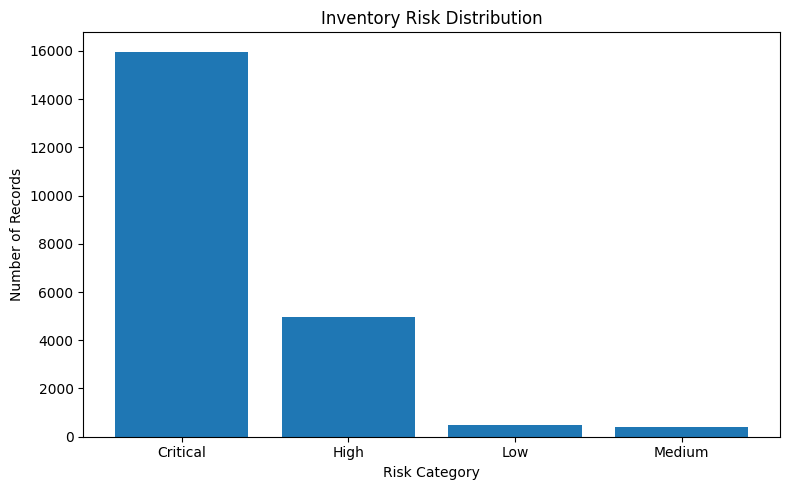

In [15]:
# Visualize inventory risk distribution

plt.figure(figsize=(8, 5))

plt.bar(
    risk_summary["risk_category"],
    risk_summary["record_count"]
)

plt.title("Inventory Risk Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

## 14. Inventory Risk Trend Over Time

This section examines how inventory risk changes over time.

The daily number of stockout records and reorder-point breaches provides an overview of periods with increased inventory pressure.

In [16]:
# Calculate daily inventory risk indicators

daily_risk_trend = (
    inventory_risk
    .groupby("date")
    .agg(
        stockout_records=("stockout_flag", "sum"),
        reorder_point_breaches=("below_reorder_point", "sum"),
        lead_time_risk_records=("lead_time_risk", "sum")
    )
    .reset_index()
)

display(daily_risk_trend.head(10))

,date,stockout_records,reorder_point_breaches,lead_time_risk_records
0,2025-01-01,1,27,35
1,2025-01-02,1,32,37
2,2025-01-03,4,29,33
3,2025-01-04,5,32,39
4,2025-01-05,11,35,39
5,2025-01-06,12,32,34
6,2025-01-07,13,31,33
7,2025-01-08,18,33,35
8,2025-01-09,16,33,34
9,2025-01-10,21,34,35


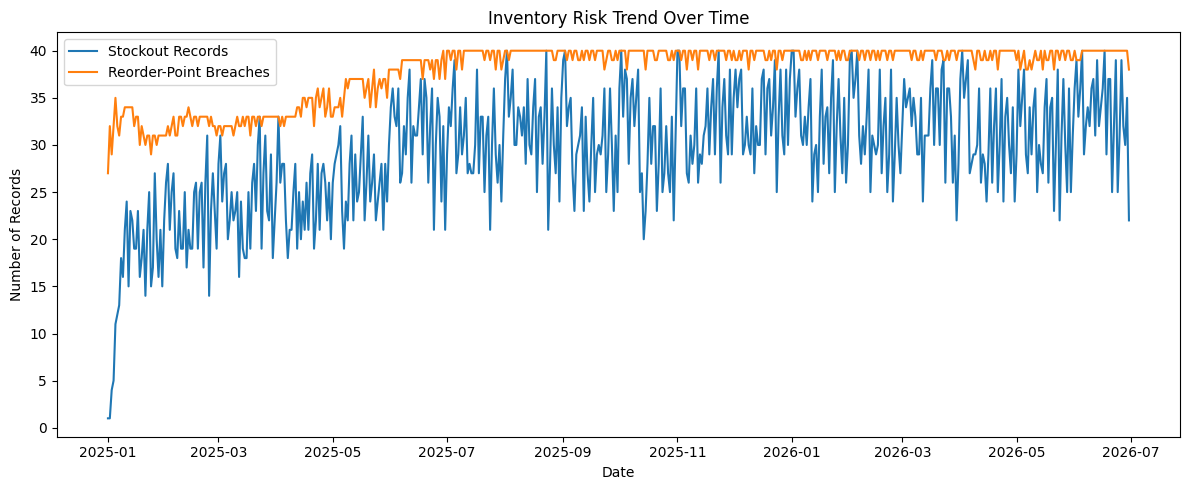

In [17]:
# Visualize stockout and reorder-point risk over time

plt.figure(figsize=(12, 5))

plt.plot(
    daily_risk_trend["date"],
    daily_risk_trend["stockout_records"],
    label="Stockout Records"
)

plt.plot(
    daily_risk_trend["date"],
    daily_risk_trend["reorder_point_breaches"],
    label="Reorder-Point Breaches"
)

plt.title("Inventory Risk Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Records")
plt.legend()

plt.tight_layout()
plt.show()

## 15. Prepare Final Inventory Risk Dataset

The calculated inventory-risk indicators are consolidated into a final dataset.

This dataset will be used by the next stage of the FORESIGHT pipeline for inventory recommendations and decision support.

In [18]:
# Select important fields for the final inventory risk dataset

inventory_risk_output = inventory_risk[
    [
        "date",
        "sku_id",
        "on_hand_units",
        "on_order_units",
        "lead_time_days",
        "reorder_point",
        "daily_demand",
        "average_daily_demand",
        "inventory_coverage_days",
        "lead_time_demand",
        "below_reorder_point",
        "stockout_flag",
        "lead_time_risk",
        "risk_category"
    ]
].copy()

print("Final inventory risk dataset shape:")
print(inventory_risk_output.shape)

display(inventory_risk_output.head(10))

Final inventory risk dataset shape:
(21840, 14)


,date,sku_id,on_hand_units,on_order_units,lead_time_days,reorder_point,daily_demand,average_daily_demand,inventory_coverage_days,lead_time_demand,below_reorder_point,stockout_flag,lead_time_risk,risk_category
0,2025-01-01,SKU001,284.0,125,6.0,255,52.0,58.959707,4.816849,353.758242,False,False,True,High
1,2025-01-02,SKU001,215.0,128,6.0,255,69.0,58.959707,3.646558,353.758242,True,False,True,High
2,2025-01-03,SKU001,166.0,186,6.0,255,49.0,58.959707,2.815482,353.758242,True,False,True,High
3,2025-01-04,SKU001,92.0,62,6.0,255,74.0,58.959707,1.560388,353.758242,True,False,True,High
4,2025-01-05,SKU001,49.0,112,6.0,255,43.0,58.959707,0.831076,353.758242,True,False,True,High
5,2025-01-06,SKU001,50.0,0,6.0,255,56.0,58.959707,0.848037,353.758242,True,False,True,High
6,2025-01-07,SKU001,4.0,64,6.0,255,46.0,58.959707,0.067843,353.758242,True,False,True,High
7,2025-01-08,SKU001,0.0,127,6.0,255,51.0,58.959707,0.000000,353.758242,True,True,True,Critical
8,2025-01-09,SKU001,0.0,43,6.0,255,65.0,58.959707,0.000000,353.758242,True,True,True,Critical
9,2025-01-10,SKU001,0.0,49,6.0,255,70.0,58.959707,0.000000,353.758242,True,True,True,Critical


## 16. Export Inventory Risk Results

The final inventory risk dataset and SKU-level risk summary are exported to the processed-data directory.

These outputs will be used by the next notebook for inventory recommendations.

In [19]:
# Export inventory risk results

import os

os.makedirs("../data/processed", exist_ok=True)

inventory_risk_output.to_csv(
    "../data/processed/inventory_risk_analysis.csv",
    index=False
)

sku_risk_summary.to_csv(
    "../data/processed/sku_risk_summary.csv",
    index=False
)

daily_risk_trend.to_csv(
    "../data/processed/daily_inventory_risk_trend.csv",
    index=False
)

print("Inventory risk outputs saved successfully.")

print("\nFiles created:")
print("- inventory_risk_analysis.csv")
print("- sku_risk_summary.csv")
print("- daily_inventory_risk_trend.csv")

Inventory risk outputs saved successfully.

Files created:
- inventory_risk_analysis.csv
- sku_risk_summary.csv
- daily_inventory_risk_trend.csv


## 17. Key Inventory Risk Findings

The inventory risk analysis identifies potential stockout conditions, reorder-point breaches, lead-time demand pressure, and low inventory coverage.

The SKU-level risk summary can be used to prioritize products requiring replenishment attention.

These outputs provide the foundation for the next stage of the FORESIGHT project: inventory recommendations and decision support.

In [20]:
# Display final inventory risk summary

print("Total inventory records:", len(inventory_risk_output))

print(
    "Total stockout records:",
    inventory_risk_output["stockout_flag"].sum()
)

print(
    "Total reorder-point breaches:",
    inventory_risk_output["below_reorder_point"].sum()
)

print(
    "Total lead-time risk records:",
    inventory_risk_output["lead_time_risk"].sum()
)

print("\nRisk category distribution:")
display(
    inventory_risk_output["risk_category"]
    .value_counts()
    .rename_axis("Risk Category")
    .reset_index(name="Records")
)

Total inventory records: 21840
Total stockout records: 15972
Total reorder-point breaches: 20652
Total lead-time risk records: 20925

Risk category distribution:


,Risk Category,Records
0,Critical,15972
1,High,4953
2,Low,504
3,Medium,411
